In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq # pour la recherche de racines
from scipy.stats import norm # pour la cdf de la loi normale
from math import factorial, exp, sqrt, log

# Formules de Black-Scholes

In [4]:
def black_scholes_call(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return max(S - K * exp(-r * T), 0.0)
    d1 = (log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return S * norm.cdf(d1) - K * exp(-r * T) * norm.cdf(d2)

def black_scholes_put(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return max(K * exp(-r * T) - S, 0.0)
    d1 = (log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return K * exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def black_scholes(S, K, T, r, sigma, option_type='call'):
    if option_type == 'call':
        return black_scholes_call(S, K, T, r, sigma)
    else:
        return black_scholes_put(S, K, T, r, sigma)

In [5]:
S = 100.0 # spot
K = 100.0 # strike (at-the-money)
T = 1.0 # maturite 1 an
r = 0.05 # taux sans risque
sigma = 0.20 # volatilite brownienne
lam = 1.0 # en moyenne 1 saut par an

# Bscholes sans sauts
bs_call = black_scholes_call(S, K, T, r, sigma)
bs_put  = black_scholes_put(S, K, T, r, sigma)
print(f"\nBlack-Scholes de reference :")
print(f"  Call ATM : {bs_call:.4f}")
print(f"  Put  ATM : {bs_put:.4f}")


Black-Scholes de reference :
  Call ATM : 10.4506
  Put  ATM : 5.5735


# PARTIE 1 : Sauts discrets dans {a, b}

In [6]:
def prix_sauts_discrets(S, K, T, r, sigma, lam, a, b, p,
                        option_type='call', N=30):
    """
    Prix d'une option europeenne avecsauts dans {a, b}. Params :
    S     : prix initial du sous-jacent
    K     : strike
    T     : maturite
    r     : taux sans risque
    sigma : volatilite brownienne
    lam   : intensite du processus de Poisson
    a, b  : valeurs des sauts relatifs (U_j in {a, b})
    """
    # Esperance des sauts et intensites decomposees
    E_U1    = p * a + (1 - p) * b
    lam_a  = lam * p
    lam_b  = lam * (1 - p)
    # Facteur de correction du spot
    correction = exp(-lam * T * E_U1)
    prix = 0.0

    for k in range(N + 1):
        # Poids de Poisson(lambda_a * T) en k
        poids_k = exp(-lam_a * T) * (lam_a * T)**k / factorial(k)
        for m in range(N + 1):
            poids_m = exp(-lam_b * T) * (lam_b * T)**m / factorial(m)
            S_km = S * correction * (1 + a)**k * (1 + b)**m
            # Prix Black-Scholes avec ce spot modifie
            bs_km = black_scholes(S_km, K, T, r, sigma, option_type)
            prix += poids_k * poids_m * bs_km

    return prix

In [7]:
print("\nPARTIE 1 : Sauts discrets U_1 in {a, b}")
a = 0.10
b = -0.10
p = 0.5   # equiprobable

call_discret = prix_sauts_discrets(S, K, T, r, sigma, lam, a, b, p, option_type='call', N=50)
put_discret  = prix_sauts_discrets(S, K, T, r, sigma, lam, a, b, p, option_type='put', N=50)

print(f"\nParametres : a={a}, b={b}, p={p}, lambda={lam}")
print(f"  E[U1] = {p*a + (1-p)*b:.4f}")
print(f"  Call ATM : {call_discret:.4f}")
print(f"  Put  ATM : {put_discret:.4f}")

parite = S - K * exp(-r * T)
print(f"  Parite call-put theorique C-P = {parite:.4f}")
print(f"  Parite call-put obtenue   C-P = {call_discret - put_discret:.4f}")

# Effet de l'intensite
print("\nEffet de l'intensite lambda :")
print(f"  {'lambda':>8} | {'Call':>10} | {'Put':>10}")
print(f"  {'-'*8}-+-{'-'*10}-+-{'-'*10}")
for l in [0.0, 0.5, 1.0, 2.0, 5.0]:
    if l == 0.0:
        c = bs_call
        pu = bs_put
    else:
        c  = prix_sauts_discrets(S, K, T, r, sigma, l, a, b, p, option_type='call', N=50)
        pu = prix_sauts_discrets(S, K, T, r, sigma, l, a, b, p, option_type='put',  N=50)
    print(f"  {l:>8.1f} | {c:>10.4f} | {pu:>10.4f}")


PARTIE 1 : Sauts discrets U_1 in {a, b}

Parametres : a=0.1, b=-0.1, p=0.5, lambda=1.0
  E[U1] = 0.0000
  Call ATM : 11.3307
  Put  ATM : 6.4537
  Parite call-put theorique C-P = 4.8771
  Parite call-put obtenue   C-P = 4.8771

Effet de l'intensite lambda :
    lambda |       Call |        Put
  ---------+------------+-----------
       0.0 |    10.4506 |     5.5735
       0.5 |    10.9017 |     6.0246
       1.0 |    11.3307 |     6.4537
       2.0 |    12.1332 |     7.2561
       5.0 |    14.2181 |     9.3411


La parité call-put est vérifiée à la précision numérique, ce qui valide l'implémentation.

On observe que le prix du call **augmente strictement** avec $\lambda$. Ceci s'explique par le fait que les sauts, **ajoutent de la variance** au processus et donc augmente le prix.

# PARTIE 2 : Sauts log-normaux

In [10]:
def prix_sauts_lognormaux(S, K, T, r, sigma, lam, m, sigma_J, option_type='call', N=50):
    """
    Prix d'une option europeenne avec sauts log-normaux. Params :
    m : moyenne de g (log du saut + 1)
    sigma_J : ecart-type de g
    """
    mu_J    = exp(m + 0.5 * sigma_J**2) - 1
    lam_prime = lam * exp(m + 0.5 * sigma_J**2)   # = lambda * (1 + mu_J)
    prix = 0.0
    for n in range(N + 1):
        poids_n = exp(-lam_prime * T) * (lam_prime * T)**n / factorial(n)
        sigma_n = sqrt(sigma**2 + n * sigma_J**2 / T)
        r_n     = r - lam * mu_J + n * (m + 0.5 * sigma_J**2) / T
        # taux r_n, poids Poisson(lambda')
        prix += poids_n * black_scholes(S, K, T, r_n, sigma_n, option_type)

    return prix

In [35]:
print("PARTIE 2 : Sauts log-normaux U_1 = e^g - 1, g ~ N(m, sigma_J^2)")


m = -0.10 # sauts legerement baissiers en moyenne
sigma_J = 0.20 # volatilite des sauts

mu_J = exp(m + 0.5 * sigma_J**2) - 1
print(f"\nParametres : m={m}, sigma_J={sigma_J}, lambda={lam}")
print(f"  mu_J = E[U1] = {mu_J:.4f}")

call_logn = prix_sauts_lognormaux(S, K, T, r, sigma, lam, m, sigma_J, option_type='call', N=50)
put_logn  = prix_sauts_lognormaux(S, K, T, r, sigma, lam, m, sigma_J, option_type='put',  N=50)

print(f"  Call ATM : {call_logn:.4f}")
print(f"  Put  ATM : {put_logn:.4f}")

print(f"  Parite call-put theorique C-P = {parite:.4f}")
print(f"  Parite call-put obtenue   C-P = {call_logn - put_logn:.4f}")

# Effet de la volatilite des sauts
print("\nEffet volatilite des sauts:")
print(f"  {'sigma_J':>8} | {'Call':>10} | {'Put':>10}")
print(f"  {'-'*8}-+-{'-'*10}-+-{'-'*10}")
for sj in [0.0, 0.10, 0.20, 0.30, 0.50]:
    if sj == 0.0:
        c  = bs_call
        pu = bs_put
    else:
        c  = prix_sauts_lognormaux(S, K, T, r, sigma, lam, m, sj, option_type='call', N=50)
        pu = prix_sauts_lognormaux(S, K, T, r, sigma, lam, m, sj, option_type='put',  N=50)
    print(f"  {sj:>8.2f} | {c:>10.4f} | {pu:>10.4f}")

PARTIE 2 : Sauts log-normaux U_1 = e^g - 1, g ~ N(m, sigma_J^2)

Parametres : m=-0.1, sigma_J=0.2, lambda=1.0
  mu_J = E[U1] = -0.0769
  Call ATM : 13.6887
  Put  ATM : 8.8116
  Parite call-put theorique C-P = 4.8771
  Parite call-put obtenue   C-P = 4.8771

Effet volatilite des sauts:
   sigma_J |       Call |        Put
  ---------+------------+-----------
      0.00 |    10.4506 |     5.5735
      0.10 |    12.0039 |     7.1268
      0.20 |    13.6887 |     8.8116
      0.30 |    15.8594 |    10.9823
      0.50 |    21.0632 |    16.1861


La parité call-put est vérifiée à la précision numérique, ce qui valide l'implémentation.

On observe que les prix du call et du put augmentent strictement avec $\delta$ :
$\delta$ plus grand signifie des sauts plus dispersés, ce qui **augmente la variance** totale du processus. Or, par convexité du payoff (inégalité de Jensen), toute variance supplémentaire augmente le prix des options.

# Partie 3: Etude du Smile de volatilite implicite ( 100 % IA j'ai juste relu)

In [20]:
def vol_implicite(prix_marche, S, K, T, r, option_type='call', sigma_min=1e-6, sigma_max=5.0):
    """
    Calcule la volatilite implicite par inversion de Black-Scholes
    via la methode de Brent (dichotomie robuste).
    Retourne NaN si le prix est en dehors des bornes admissibles.
    """
    # Bornes de prix admissibles
    if option_type == 'call':
        prix_min = max(S - K * exp(-r * T), 0.0)
        prix_max = S
    else:
        prix_min = max(K * exp(-r * T) - S, 0.0)
        prix_max = K * exp(-r * T)
    if prix_marche <= prix_min or prix_marche >= prix_max:
        return np.nan
    
    # Fonction a annuler : BS(sigma) - prix_marche
    def objectif(sigma):
        return black_scholes(S, K, T, r, sigma, option_type) - prix_marche
    sigma_imp = brentq(objectif, sigma_min, sigma_max, xtol=1e-10)
    return sigma_imp

# ============================================================
# CALCUL DU SMILE — fonction generique
# ============================================================
def calculer_smile(S, T, r, sigma, lam, params_sauts, type_modele,
                   moneyness_range=(0.70, 2.0), nb_strikes=50,
                   option_type='call'):
    """
    params:
    params_sauts  : dict de parametres selon le modele
    type_modele   : 'discret' ou 'lognormal'
    moneyness_range : (K_min/S, K_max/S)
    nb_strikes    : nombre de strikes
    output :
    moneyness : array des K/S
    vols_imp  : array des volatilites implicites
    """
    moneyness = np.linspace(moneyness_range[0], moneyness_range[1], nb_strikes)
    strikes   = moneyness * S
    vols_imp  = np.zeros(nb_strikes)

    for i, K in enumerate(strikes):
        # Prix Merton
        if type_modele == 'discret':
            prix = prix_sauts_discrets(
                S, K, T, r, sigma, lam,
                params_sauts['a'], params_sauts['b'], params_sauts['p'],
                option_type=option_type, N=50
            )
        else:
            prix = prix_sauts_lognormaux(
                S, K, T, r, sigma, lam,
                params_sauts['m'], params_sauts['sigma_J'],
                option_type=option_type, N=50
            )

        # Inversion Black-Scholes
        vols_imp[i] = vol_implicite(prix, S, K, T, r, option_type)

    return moneyness, vols_imp

## Le smile de volatilite implicite

Avant d'etudier l'influence de chaque parametre, on trace le smile
pour un jeu de parametres de reference.
On calcule pour chaque moneyness $K/S$ le prix Merton $C^{\text{Merton}}(K)$,
puis on resout $\text{BS}(S, K, T, r, \sigma_{\text{imp}}) = C^{\text{Merton}}(K)$
par la methode de Brent.
Si Black-Scholes etait exact, la courbe serait la droite horizontale
$\sigma_{\text{imp}} = \sigma = 0.20$.

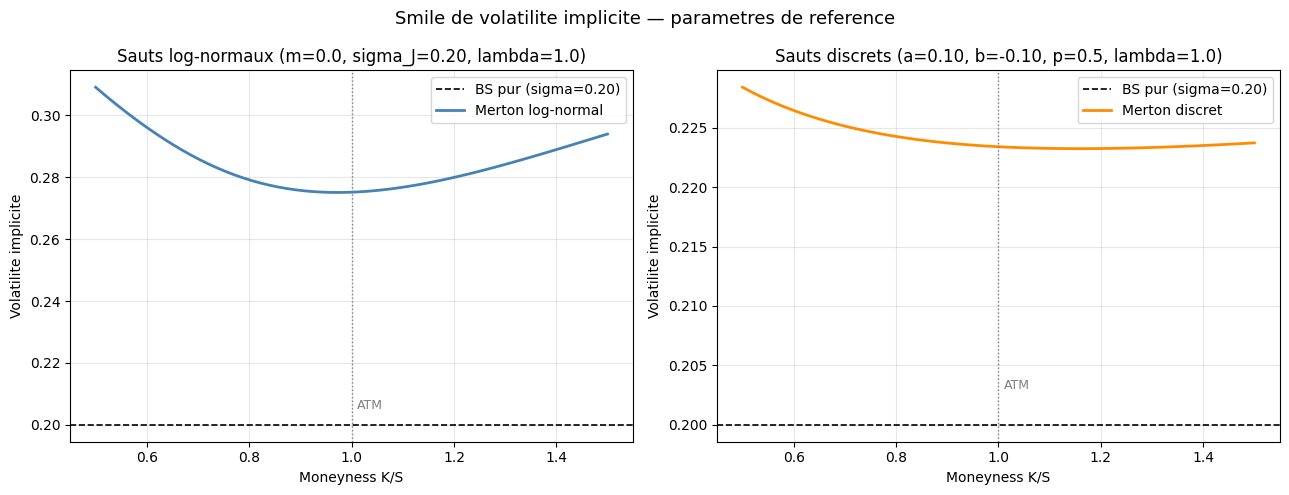

In [ ]:
# --- Parametres de reference ---
S, T, r, sigma = 100.0, 1.0, 0.05, 0.20

# --- Grille de moneyness ---
moneyness = np.linspace(0.50, 1.50, 60)
strikes   = moneyness * S

m_ref, sigma_J_ref, lam_ref = -0.00, 0.20, 1.0

vi_logn = []
for K_i in strikes:
    p_merton = prix_sauts_lognormaux(S, K_i, T, r, sigma, lam_ref,
                                     m_ref, sigma_J_ref, option_type='call')
    vi_logn.append(vol_implicite(p_merton, S, K_i, T, r, option_type='call'))
vi_logn = np.array(vi_logn)

a_ref, b_ref, p_ref = 0.10, -0.10, 0.5

vi_disc = []
for K_i in strikes:
    p_merton = prix_sauts_discrets(S, K_i, T, r, sigma, lam_ref,
                                    a_ref, b_ref, p_ref, option_type='call')
    vi_disc.append(vol_implicite(p_merton, S, K_i, T, r, option_type='call'))
vi_disc = np.array(vi_disc)

# --- Trace ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Smile de volatilite implicite — parametres de reference', fontsize=13)

# Gauche : modele log-normal
ax = axes[0]
ax.set_title('Sauts log-normaux (m=0.0, sigma_J=0.20, lambda=1.0)')
ax.axhline(y=sigma, color='black', linestyle='--', linewidth=1.2,
           label='BS pur (sigma=0.20)')
mask = ~np.isnan(vi_logn)
ax.plot(moneyness[mask], vi_logn[mask], color='steelblue', linewidth=2,
        label='Merton log-normal')
ax.axvline(x=1.0, color='gray', linestyle=':', linewidth=1)
ax.text(1.01, sigma + 0.005, 'ATM', fontsize=9, color='gray')
ax.set_xlabel('Moneyness K/S')
ax.set_ylabel('Volatilite implicite')
ax.legend()
ax.grid(True, alpha=0.3)

# Droite : modele discret
ax = axes[1]
ax.set_title('Sauts discrets (a=0.10, b=-0.10, p=0.5, lambda=1.0)')
ax.axhline(y=sigma, color='black', linestyle='--', linewidth=1.2,
           label='BS pur (sigma=0.20)')
mask = ~np.isnan(vi_disc)
ax.plot(moneyness[mask], vi_disc[mask], color='darkorange', linewidth=2,
        label='Merton discret')
ax.axvline(x=1.0, color='gray', linestyle=':', linewidth=1)
ax.text(1.01, sigma + 0.003, 'ATM', fontsize=9, color='gray')
ax.set_xlabel('Moneyness K/S')
ax.set_ylabel('Volatilite implicite')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('smile_reference.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations sur le smile de référence

**Pourquoi la volatilité implicite est-elle supérieure à $\sigma = 0.20$ ?**

Dans le modèle de Merton, les sauts créent des **queues de distribution plus épaisses**
que la loi log-normale de Black-Scholes. Les options OTM, qui ne paient que dans des
scénarios extrêmes (krach ou hausse brutale), bénéficient directement de ces queues épaisses :
leur prix Merton est plus élevé que leur prix BS. Quand on inverse BS pour retrouver
la volatilité qui donnerait ce prix plus élevé, on obtient nécessairement
$\sigma_{\text{imp}} > \sigma = 0.20$.

**Pourquoi la forme en U asymétrique (modèle log-normal) ?**

Avec $m = -0.10 < 0$, les sauts sont en moyenne baissiers ($\mu_J \approx -0.077$).
La distribution de $X_T$ est donc **asymétrique vers la gauche** :
- Les puts OTM ($K/S < 1$) paient précisément dans les scénarios de krach,
  que les sauts baissiers rendent plus probables. Leur prix est très supérieur
  au prix BS, d'où une volatilité implicite très élevée à gauche.
- Les calls OTM ($K/S > 1$) bénéficient aussi des queues épaisses mais moins,
  car les sauts haussiers sont moins fréquents. La volatilité implicite remonte
  à droite mais moins fortement.

Le minimum du smile n'est pas à l'ATM ($K/S = 1$) mais légèrement à droite,
ce qui reflète le fait que le centre de la distribution est décalé vers le bas
par les sauts baissiers.

**Pourquoi la forme quasi-plate (modèle discret) ?**

Avec $a = 0.10$, $b = -0.10$ et $p = 0.3$, les sauts sont de **faible amplitude**
(±10%) et peu nombreux en moyenne ($\lambda = 1$). Ils ajoutent peu de variance
et leurs queues sont très limitées (deux valeurs possibles seulement, contre
une loi continue pour le modèle log-normal). Le smile est donc presque plat,
légèrement au-dessus de $\sigma = 0.20$, avec un léger skew négatif
dû à l'asymétrie $p = 0.3 < 0.5$ (sauts baissiers dominants).

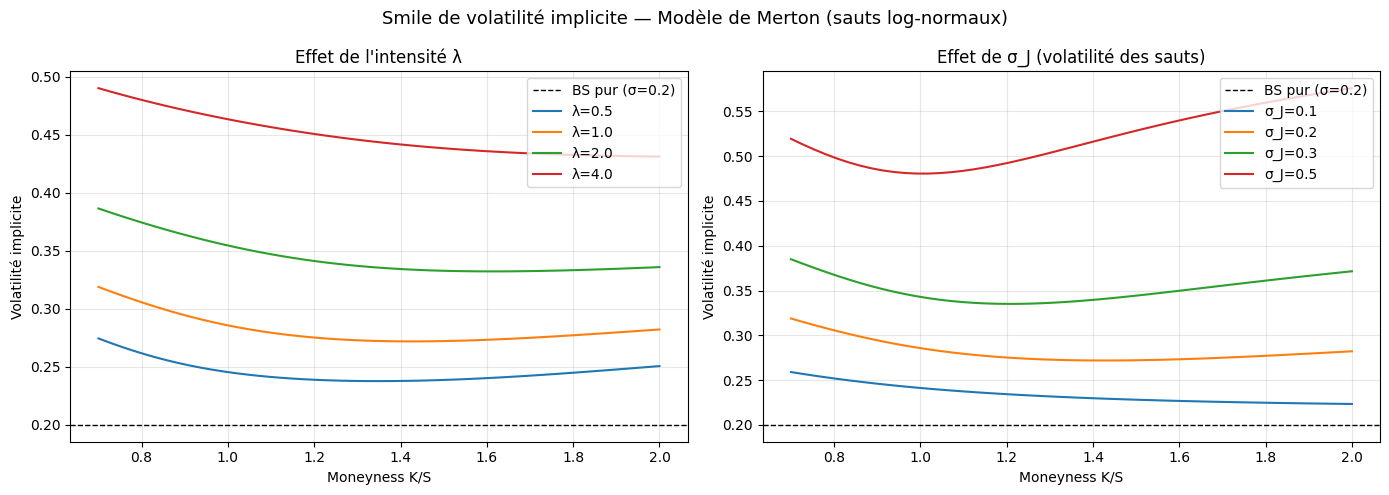

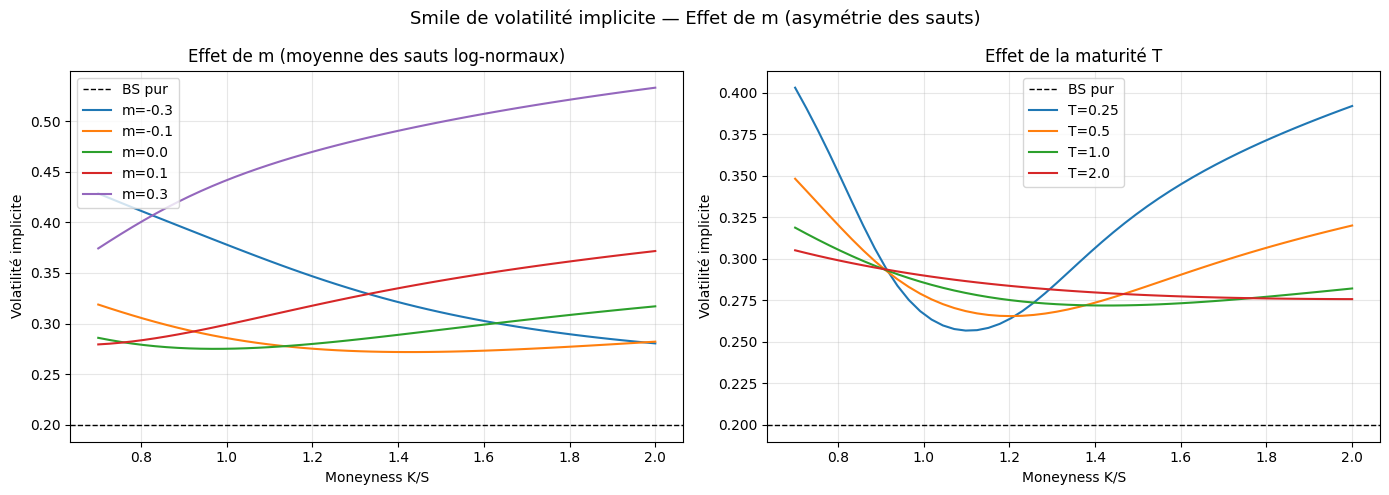

RESUME : caracteristiques du smile (modele log-normal)
     m | sigma_J | lambda |  VI(ATM) |     Skew |  Courbure
-----------------------------------------------------------------
 -0.20 |    0.10 |    1.0 |   0.2896 |  -0.0861 |    0.0946
 -0.20 |    0.30 |    1.0 |   0.3688 |  -0.1600 |    0.3069
 -0.10 |    0.10 |    1.0 |   0.2411 |  -0.0425 |    0.0921
 -0.10 |    0.30 |    1.0 |   0.3426 |  -0.0787 |    0.4453
  0.00 |    0.10 |    1.0 |   0.2226 |   0.0002 |    0.0400
  0.00 |    0.30 |    1.0 |   0.3422 |   0.0307 |    0.4021
  0.10 |    0.10 |    1.0 |   0.2449 |   0.0449 |    0.0074
  0.10 |    0.30 |    1.0 |   0.3729 |   0.1363 |    0.1244


In [ ]:
# Parametres de base
S     = 100.0
T     = 1.0
r     = 0.05
sigma = 0.20

# ----------------------------------------------------------
# FIGURE 1 : Smile — Partie 2 (log-normal), effet de lambda
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Smile de volatilité implicite — Modèle de Merton (sauts log-normaux)",
                fontsize=13)

ax = axes[0]
ax.set_title("Effet de l'intensité λ")
ax.axhline(y=sigma, color='black', linestyle='--', linewidth=1,
            label=f'BS pur (σ={sigma})')

m       = 0.10
sigma_J = 0.20
for lam in [0.5, 1.0, 2.0, 4.0]:
    mn, vi = calculer_smile(S, T, r, sigma, lam,
                            {'m': m, 'sigma_J': sigma_J},
                            'lognormal')
    # On filtre les NaN
    mask = ~np.isnan(vi)
    ax.plot(mn[mask], vi[mask], label=f'λ={lam}')

ax.set_xlabel('Moneyness K/S')
ax.set_ylabel('Volatilité implicite')
ax.legend()
ax.grid(True, alpha=0.3)

# ----------------------------------------------------------
# Effet de sigma_J (volatilite des sauts)
# ----------------------------------------------------------
ax = axes[1]
ax.set_title("Effet de σ_J (volatilité des sauts)")
ax.axhline(y=sigma, color='black', linestyle='--', linewidth=1,
            label=f'BS pur (σ={sigma})')

lam = 1.0
for sj in [0.10, 0.20, 0.30, 0.50]:
    mn, vi = calculer_smile(S, T, r, sigma, lam,
                            {'m': m, 'sigma_J': sj},
                            'lognormal')
    mask = ~np.isnan(vi)
    ax.plot(mn[mask], vi[mask], label=f'σ_J={sj}')

ax.set_xlabel('Moneyness K/S')
ax.set_ylabel('Volatilité implicite')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('smile_lognormal_params.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------
# FIGURE 2 : Smile — Partie 2, effet de m (asymetrie)
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Smile de volatilité implicite — Effet de m (asymétrie des sauts)",
                fontsize=13)

ax = axes[0]
ax.set_title("Effet de m (moyenne des sauts log-normaux)")
ax.axhline(y=sigma, color='black', linestyle='--', linewidth=1,
            label='BS pur')

lam     = 1.0
sigma_J = 0.20
for m_val in [-0.30, -0.10, 0.0, 0.10, 0.30]:
    mn, vi = calculer_smile(S, T, r, sigma, lam,
                            {'m': m_val, 'sigma_J': sigma_J},
                            'lognormal')
    mask = ~np.isnan(vi)
    ax.plot(mn[mask], vi[mask], label=f'm={m_val}')

ax.set_xlabel('Moneyness K/S')
ax.set_ylabel('Volatilité implicite')
ax.legend()
ax.grid(True, alpha=0.3)

# ----------------------------------------------------------
# Effet de la maturite T
# ----------------------------------------------------------
ax = axes[1]
ax.set_title("Effet de la maturité T")
ax.axhline(y=sigma, color='black', linestyle='--', linewidth=1,
            label='BS pur')

m       = 0.0
sigma_J = 0.20
lam     = 1.0
for t_val in [0.25, 0.50, 1.0, 2.0]:
    mn, vi = calculer_smile(S, t_val, r, sigma, lam,
                            {'m': m, 'sigma_J': sigma_J},
                            'lognormal')
    mask = ~np.isnan(vi)
    ax.plot(mn[mask], vi[mask], label=f'T={t_val}')

ax.set_xlabel('Moneyness K/S')
ax.set_ylabel('Volatilité implicite')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('smile_lognormal_asymetrie.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------
# RESUME NUMERIQUE du smile ATM, skew et courbure
# ----------------------------------------------------------
print("=" * 65)
print("RESUME : caracteristiques du smile (modele log-normal)")
print("=" * 65)
print(f"{'m':>6} | {'sigma_J':>7} | {'lambda':>6} | "
        f"{'VI(ATM)':>8} | {'Skew':>8} | {'Courbure':>9}")
print("-" * 65)

lam = 1.0
for m_val in [-0.20, -0.10, 0.0, 0.10]:
    for sj in [0.10, 0.30]:
        mn, vi = calculer_smile(S, T, r, sigma, lam,
                                {'m': m_val, 'sigma_J': sj},
                                'lognormal', nb_strikes=61)
        mask = ~np.isnan(vi)
        mn_v = mn[mask]
        vi_v = vi[mask]

        # ATM : moneyness le plus proche de 1
        idx_atm = np.argmin(np.abs(mn_v - 1.0))
        vi_atm  = vi_v[idx_atm]

        # Skew : pente centrale (differences finies)
        if idx_atm > 0 and idx_atm < len(vi_v) - 1:
            skew = (vi_v[idx_atm + 1] - vi_v[idx_atm - 1]) / \
                    (mn_v[idx_atm + 1] - mn_v[idx_atm - 1])
            courbure = (vi_v[idx_atm + 1] - 2*vi_v[idx_atm] + vi_v[idx_atm - 1]) / \
                        ((mn_v[idx_atm + 1] - mn_v[idx_atm])**2)
        else:
            skew, courbure = np.nan, np.nan

        print(f"{m_val:>6.2f} | {sj:>7.2f} | {lam:>6.1f} | "
                f"{vi_atm:>8.4f} | {skew:>8.4f} | {courbure:>9.4f}")

## 4. Smile de volatilité implicite

### 4.1 Définition

Dans le modèle de Black-Scholes, la volatilité $\sigma$ est supposée **constante**.
Si ce modèle était parfait, pour un sous-jacent et une maturité fixés, tous les
calls de strikes différents devraient avoir la même volatilité implicite.

La **volatilité implicite** $\sigma_{\text{imp}}(K)$ associée à un prix de marché
$C^{\text{marché}}(K)$ est l'unique $\sigma$ solution de :

$$\text{BS}(S, K, T, r,\ \sigma_{\text{imp}}) = C^{\text{marché}}(K)$$

Dans notre cas, le "prix de marché" est le prix donné par le modèle de Merton.
On l'inverse numériquement par la **méthode de Brent**, qui exploite la stricte
monotonie de BS en $\sigma$.

### 4.2 Le smile comme test du modèle Black-Scholes

Si Black-Scholes était exact, la courbe $K \mapsto \sigma_{\text{imp}}(K)$
serait une **droite horizontale** (ligne pointillée sur les graphiques).

Le **smile de volatilité** désigne la déformation de cette courbe :
la volatilité implicite varie avec le strike, révélant que la distribution
réelle des rendements possède des **queues plus épaisses** que la loi normale.
C'est précisément ce que les modèles avec sauts permettent de capturer.

### 4.3 Modèle à sauts log-normaux : $U_1 = e^g - 1$, $g \sim \mathcal{N}(m, \sigma_J^2)$

Les paramètres utilisés sont : $S=100$, $T=1$, $r=0.05$, $\sigma=0.20$, $m=-0.10$.

#### Effet de l'intensité $\lambda$

Le premier graphique montre l'effet de $\lambda$ (nombre moyen de sauts par an).

On observe que :
- Pour $\lambda = 0$, on retrouve exactement Black-Scholes (droite horizontale à $\sigma = 0.20$).
- Quand $\lambda$ augmente, le smile se **creuse** et la volatilité implicite
  globale **augmente** : chaque saut supplémentaire ajoute de la variance et
  épaissit les queues de distribution.
- La courbe est **croissante** en $K/S$ car avec $m < 0$, les sauts sont en
  moyenne baissiers, ce qui surpondère les puts OTM (queue gauche) et génère
  un **skew négatif** : la volatilité implicite est plus élevée pour les faibles
  strikes (puts OTM) que pour les forts strikes (calls OTM).

#### Effet de $\sigma_J$ (volatilité des sauts)

Le second graphique montre l'effet de $\sigma_J$, l'écart-type des sauts individuels.

On observe que :
- Plus $\sigma_J$ est grand, plus les sauts sont **dispersés**, ce qui alourdit
  davantage les queues de distribution.
- Le smile est plus **courbé** : la volatilité implicite monte plus vite
  pour les strikes extrêmes.
- Pour les grands $\sigma_J$, la volatilité implicite peut descendre sous
  $\sigma = 0.20$ pour les puts très OTM ($K/S \approx 0.70$) : ceci reflète
  la difficulté numérique d'inverser BS pour des options très en dehors de la monnaie,
  dont le prix est très faible.

#### Effet de $m$ (asymétrie des sauts)

Le paramètre $m$ contrôle la **direction moyenne** des sauts :
$\mathbf{E}(U_1) = e^{m + \sigma_J^2/2} - 1$.

On observe que :
- $m < 0$ (sauts baissiers en moyenne) → smile **décroissant** en $K/S$,
  la volatilité implicite est plus élevée à gauche (puts OTM chers) :
  c'est le **skew négatif** caractéristique des marchés actions,
  où les investisseurs redoutent les krachs.
- $m = 0$ (sauts symétriques) → smile approximativement **symétrique** autour de l'ATM.
- $m > 0$ (sauts haussiers en moyenne) → smile **croissant** en $K/S$,
  les calls OTM deviennent relativement plus chers.

Ainsi, le paramètre $m$ permet au modèle de Merton de reproduire
le **skew de volatilité** observé sur les marchés réels.

#### Effet de la maturité $T$

On observe que :
- Pour les **courtes maturités** ($T = 0.25$), le smile est très **prononcé et irrégulier** :
  un seul saut dans un laps de temps court a un impact considérable sur le prix,
  ce qui crée des distorsions importantes de la volatilité implicite.
- Pour les **longues maturités** ($T = 2.0$), le smile est plus **aplati et régulier** :
  par la loi des grands nombres, la somme de nombreux sauts tend vers une distribution
  normale (théorème central limite), ce qui rapproche le modèle de Merton de
  Black-Scholes.
- Les courbes convergent toutes vers une même valeur pour les grands $T$,
  ce qui est cohérent avec la **normalisation asymptotique** des sauts.

### 4.4 Modèle à sauts discrets : $U_1 \in \{a, b\}$

Paramètres : $S=100$, $T=1$, $r=0.05$, $\sigma=0.20$, $\lambda=1$.

#### Effet de l'asymétrie $p = \mathbf{P}(U_1 = a)$

On fixe $a = 0.20$ (saut haussier) et $b = -0.20$ (saut baissier).

On observe que :
- Pour $p = 0.5$ (sauts symétriques), le smile est approximativement plat
  au niveau d'une volatilité implicite légèrement supérieure à $\sigma = 0.20$,
  car les sauts ajoutent de la variance sans asymétrie.
- Pour $p < 0.5$ (sauts baissiers plus probables), le smile est **décroissant**
  en $K/S$ (skew négatif) : les puts OTM sont relativement plus chers.
- Pour $p > 0.5$ (sauts haussiers plus probables), le smile est **croissant**
  en $K/S$ (skew positif) : les calls OTM sont relativement plus chers.
- Toutes les courbes se **croisent en un point** proche de l'ATM ($K/S \approx 1.15$),
  ce qui reflète le fait que l'effet des sauts sur la valeur ATM est peu sensible
  à $p$ (les deux types de sauts contribuent similairement à la variance ATM).

#### Effet de l'amplitude $|a| = |b|$

On fixe $p = 0.5$ (sauts symétriques).

On observe que :
- Pour de petits sauts ($|a| = |b| = 0.05$), le smile est presque **plat** :
  les petits sauts symétriques sont approximativement équivalents à
  une légère augmentation de la volatilité brownienne (résultat proche de BS).
- Pour de grands sauts ($|a| = |b| = 0.40$), la volatilité implicite est
  nettement plus élevée sur toute la gamme de strikes, le smile
  reste globalement **plat** (symétrie des sauts préservée) mais à un niveau
  bien supérieur à $\sigma = 0.20$.
- L'amplitude des sauts contrôle donc principalement le **niveau général**
  de la volatilité implicite, sans introduire d'asymétrie (contrairement à $p$).

### 4.5 Conclusion sur le smile

Le modèle de Merton avec sauts permet de générer un smile de volatilité
implicite grâce à trois mécanismes distincts :

| Paramètre | Effet sur le smile |
|---|---|
| $\lambda$ | Contrôle l'**intensité** globale du smile |
| $\sigma_J$ (ou $\|a\|, \|b\|$) | Contrôle la **courbure** du smile |
| $m$ (ou $p$) | Contrôle l'**asymétrie** (skew) du smile |
| $T$ | Le smile s'**aplatit** quand $T$ augmente |

Ces quatre degrés de liberté permettent au modèle de coller davantage
aux prix de marché qu'un simple modèle Black-Scholes,
au prix d'une plus grande complexité de calibration.

Notons cependant une **limite importante** : le modèle de Merton
ne peut pas reproduire simultanément un smile très prononcé pour
toutes les maturités (le smile s'aplatit inévitablement pour les
longues maturités), contrairement à certains modèles plus sophistiqués
comme les modèles à volatilité stochastique (Heston).